# Training Patch Classifiers from Per-Class Patch Folders

Click to open in: [[GitHub](https://github.com/TissueImageAnalytics/tiatoolbox/blob/develop/examples/13-training-patch-folder-classification.ipynb)][[Colab](https://colab.research.google.com/github/TissueImageAnalytics/tiatoolbox/blob/develop/examples/13-training-patch-folder-classification.ipynb)]


## About this notebook

This Jupyter notebook can run on a local Python environment or on Google Colab. If you run it on Colab, use the installation cell below and restart the runtime once installation finishes.


## About this demo

This example demonstrates model training for **case 1** in the training roadmap: per-class patch folders where each subfolder name defines the target class.

You will:

1. Create a small folder-structured patch dataset.
1. Build a `PatchFolderClassificationDataset`.
1. Train a classifier with `Trainer` and `ClassificationTask`.
1. Inspect generated checkpoints and resume training from `last.ckpt`.


## Optional: Colab setup

Skip this section when running in an environment where `tiatoolbox` is already installed.


In [ ]:
%%bash
apt-get -y install libopenjp2-7-dev libopenjp2-tools openslide-tools libpixman-1-dev | tail -n 1
pip install git+https://github.com/TissueImageAnalytics/tiatoolbox.git@develop | tail -n 1
echo "Installation is done."


If you are using Colab and ran the installation cell for the first time, restart the runtime before continuing.


## Imports and configuration


In [1]:
from collections import defaultdict
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
import zarr

from tiatoolbox.models.engine.patch_predictor import PatchPredictor
from tiatoolbox.models.training import (
    ClassificationTask,
    PatchFolderClassificationDataset,
    Trainer,
    TrainerConfig,
)
from tiatoolbox.utils.misc import imread, imwrite

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


|2026-02-17|18:09:47.484| [WARNING] /home/mark-eastwood/miniforge3/envs/comfyui/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Using device: cuda


## Create a synthetic per-class patch dataset

For a self-contained example, we generate synthetic patches and save them as PNG files using the expected folder structure.


In [2]:
dataset_root = Path("tmp/patch_folder_training_demo")
if dataset_root.exists():
    shutil.rmtree(dataset_root)
dataset_root.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(7)
class_specs = {
    "tumor": np.array([175, 70, 120], dtype=np.float32),
    "stroma": np.array([120, 165, 95], dtype=np.float32),
    "necrosis": np.array([200, 200, 120], dtype=np.float32),
}
patch_size = 64
samples_per_class = 60

for class_name, base_color in class_specs.items():
    class_dir = dataset_root / class_name
    class_dir.mkdir(parents=True, exist_ok=True)

    for sample_idx in range(samples_per_class):
        patch = np.ones((patch_size, patch_size, 3), dtype=np.float32) * base_color
        patch += rng.normal(0, 18, size=patch.shape)

        if class_name == "tumor":
            patch[:, ::4, 0] += 35
            patch[::4, :, 2] += 20
        elif class_name == "stroma":
            patch[:, ::6, 1] += 35
            patch[::6, :, 1] += 35
        else:
            yy, xx = np.ogrid[:patch_size, :patch_size]
            center = patch_size // 2
            radius = patch_size // 3
            core = (xx - center) ** 2 + (yy - center) ** 2 < radius**2
            patch[core] += np.array([30, 30, -20], dtype=np.float32)

        patch = np.clip(patch, 0, 255).astype(np.uint8)
        imwrite(class_dir / f"{class_name}_{sample_idx:03d}.png", patch)

print(f"Dataset path: {dataset_root.resolve()}")
for class_dir in sorted(dataset_root.iterdir()):
    patch_count = len(list(class_dir.glob("*.png")))
    print(f"{class_dir.name}: {patch_count} patches")


Dataset path: /media/mark-eastwood/Work/tiatoolbox/examples/tmp/patch_folder_training_demo
necrosis: 60 patches
stroma: 60 patches
tumor: 60 patches


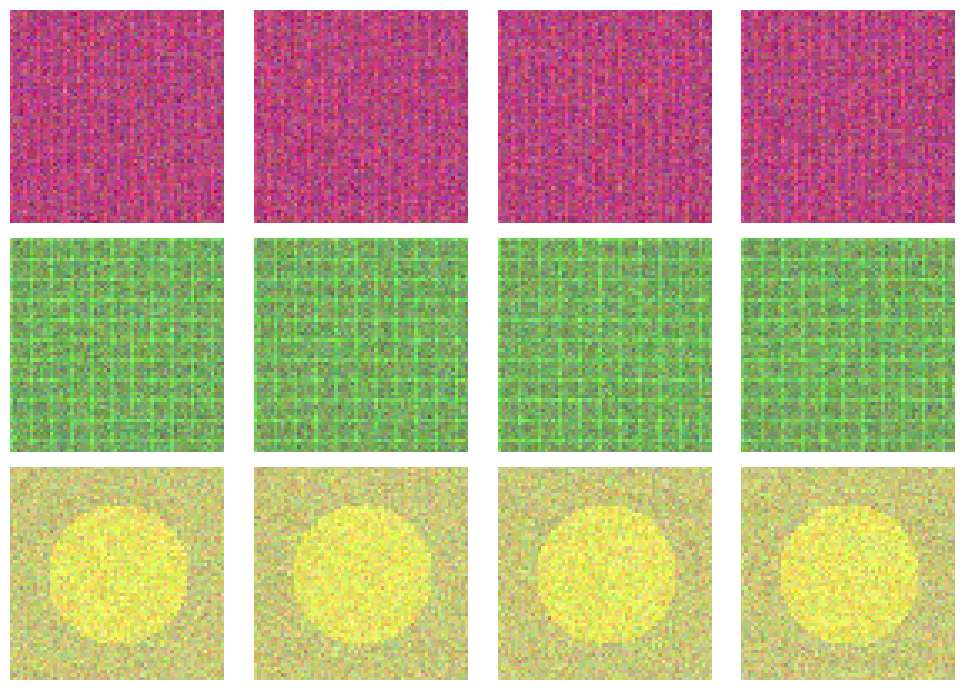

In [3]:
fig, axes = plt.subplots(len(class_specs), 4, figsize=(10, 7))
for row_index, class_name in enumerate(class_specs):
    sample_paths = sorted((dataset_root / class_name).glob("*.png"))[:4]
    for col_index, sample_path in enumerate(sample_paths):
        image = plt.imread(sample_path)
        axes[row_index, col_index].imshow(image)
        axes[row_index, col_index].axis("off")
    axes[row_index, 0].set_ylabel(class_name, rotation=90, size=11)

plt.tight_layout()


## Build dataset and dataloaders


In [4]:
dataset = PatchFolderClassificationDataset(root_dir=dataset_root)
print(f"Total patches: {len(dataset)}")
print("Class mapping:", dataset.class_to_idx)

def stratified_split_indices(samples, val_fraction=0.2, seed=123):
    rng = np.random.default_rng(seed)
    grouped = defaultdict(list)
    for item_index, (_, class_index) in enumerate(samples):
        grouped[class_index].append(item_index)

    train_indices = []
    val_indices = []
    for indices in grouped.values():
        indices = np.array(indices)
        rng.shuffle(indices)
        n_val = max(1, int(len(indices) * val_fraction))
        val_indices.extend(indices[:n_val].tolist())
        train_indices.extend(indices[n_val:].tolist())

    return train_indices, val_indices

train_indices, val_indices = stratified_split_indices(
    dataset.samples,
    val_fraction=0.2,
    seed=5,
)

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

print(f"Train patches: {len(train_dataset)}")
print(f"Val patches:   {len(val_dataset)}")


Total patches: 180
Class mapping: {'necrosis': 0, 'stroma': 1, 'tumor': 2}
Train patches: 144
Val patches:   36


In [5]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print("Image batch shape:", tuple(batch["image"].shape))
print("Target batch shape:", tuple(batch["target"].shape))
print("Image dtype:", batch["image"].dtype)
print("Target dtype:", batch["target"].dtype)


Image batch shape: (16, 3, 64, 64)
Target batch shape: (16,)
Image dtype: torch.float32
Target dtype: torch.int64


## Define model and trainer

The training loop is task-agnostic and only requires a PyTorch model that returns logits.


In [6]:
num_classes = len(dataset.class_to_idx)

class ToyPatchClassifier(nn.Module):
    def __init__(self, num_output_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(32, num_output_classes),
        )
        self.preproc_func = self.preproc
        self.postproc_func = self.postproc
        self.class_dict = None

    def forward(self, imgs):
        return self.net(imgs)

    @staticmethod
    def preproc(image):
        image = image.astype(np.float32)
        if image.max() > 1:
            image = image / 255.0
        return image

    @staticmethod
    def postproc(probabilities):
        return np.argmax(probabilities, axis=-1)

    @staticmethod
    def infer_batch(model, batch_data, *, device="cpu"):
        batch_data = batch_data.to(device=device).type(torch.float32)
        batch_data = batch_data.permute(0, 3, 1, 2).contiguous()

        model.eval()
        with torch.inference_mode():
            logits = model(batch_data)
            probabilities = torch.softmax(logits, dim=-1)
        return probabilities.cpu().numpy()

def build_model(num_output_classes):
    return ToyPatchClassifier(num_output_classes)

model = build_model(num_classes)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=8, eta_min=1e-5)

output_dir = Path("tmp/patch_folder_training_run")
output_dir.mkdir(parents=True, exist_ok=True)

trainer = Trainer(
    model=model,
    task=ClassificationTask(loss="cross_entropy"),
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TrainerConfig(
        max_epochs=18,
        device=device,
        amp=True,
        seed=42,
        output_dir=output_dir,
        monitor="val_loss",
        monitor_mode="min",
        log_every_n_steps=0,
    ),
)


|2026-02-17|18:09:51.761| [WARNING] /media/mark-eastwood/Work/tiatoolbox/tiatoolbox/models/training/trainer.py:150: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.grad_scaler = GradScaler(enabled=self.use_amp)



## Train the model


In [7]:
history = trainer.fit()
print(f"Finished epochs: {len(history)}")
print(f"Best epoch: {trainer.best_epoch}")
history[-1]


|2026-02-17|18:09:51.770| [WARNING] /media/mark-eastwood/Work/tiatoolbox/tiatoolbox/models/training/trainer.py:266: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):



|2026-02-17|18:09:52.270| [INFO] Epoch 1/18 | monitor `val_loss`=1.052056 | best=1.052056
|2026-02-17|18:09:52.304| [INFO] Epoch 2/18 | monitor `val_loss`=0.986518 | best=0.986518
|2026-02-17|18:09:52.337| [INFO] Epoch 3/18 | monitor `val_loss`=0.892036 | best=0.892036
|2026-02-17|18:09:52.371| [INFO] Epoch 4/18 | monitor `val_loss`=0.787882 | best=0.787882
|2026-02-17|18:09:52.404| [INFO] Epoch 5/18 | monitor `val_loss`=0.686707 | best=0.686707
|2026-02-17|18:09:52.438| [INFO] Epoch 6/18 | monitor `val_loss`=0.624003 | best=0.624003
|2026-02-17|18:09:52.472| [INFO] Epoch 7/18 | monitor `val_loss`=0.596069 | best=0.596069
|2026-02-17|18:09:52.506| [INFO] Epoch 8/18 | monitor `val_loss`=0.587979 | best=0.587979
|2026-02-17|18:09:52.539| [INFO] Epoch 9/18 | monitor `val_loss`=0.586392 | best=0.586392
|2026-02-17|18:09:52.571| [INFO] Epoch 10/18 | monitor `val_loss`=0.579000 | best=0.579000
|2026-02-17|18:09:52.604| [INFO] Epoch 11/18 | monitor `val_loss`=0.556261 | best=0.556261
|2026-02

{'epoch': 18.0,
 'train_loss': 0.1475319332546658,
 'train_accuracy': 1.0,
 'train_f1': 1.0,
 'val_loss': 0.11805555555555555,
 'val_accuracy': 1.0,
 'val_f1': 0.6296296296296295}

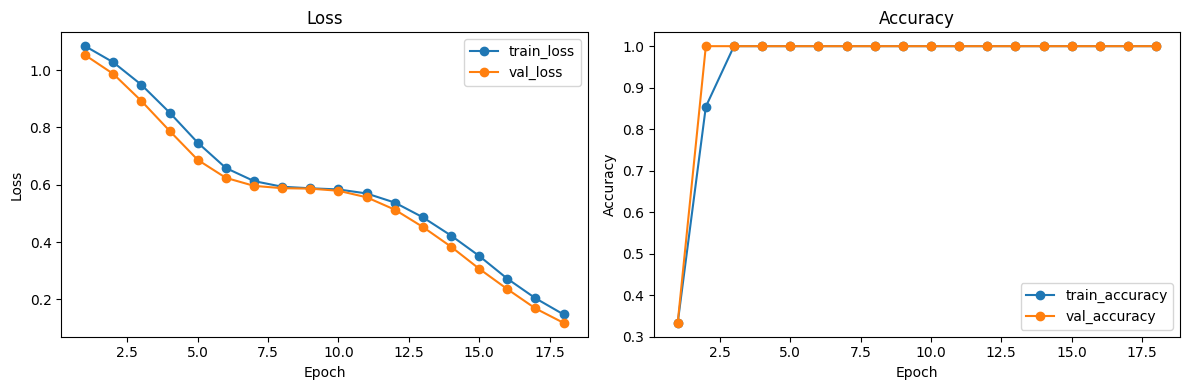

In [8]:
epochs = [int(record["epoch"]) for record in history]
train_loss = [record["train_loss"] for record in history]
val_loss = [record.get("val_loss", np.nan) for record in history]
train_acc = [record["train_accuracy"] for record in history]
val_acc = [record.get("val_accuracy", np.nan) for record in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, marker="o", label="train_loss")
axes[0].plot(epochs, val_loss, marker="o", label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, train_acc, marker="o", label="train_accuracy")
axes[1].plot(epochs, val_acc, marker="o", label="val_accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()


## Checkpoints and resume

`Trainer` writes `last.ckpt` (full state) and `best_model_weights.pth` (weights only).


In [9]:
print("Saved checkpoint artifacts:")
for path in sorted(output_dir.glob("*")):
    print("-", path.name)

resumed_model = build_model(num_classes)
resumed_optimizer = torch.optim.AdamW(
    resumed_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
resumed_scheduler = CosineAnnealingLR(
    resumed_optimizer,
    T_max=10,
    eta_min=1e-5,
)

resumed_trainer = Trainer(
    model=resumed_model,
    task=ClassificationTask(loss="cross_entropy"),
    optimizer=resumed_optimizer,
    scheduler=resumed_scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TrainerConfig(
        max_epochs=20,
        device=device,
        amp=True,
        seed=42,
        output_dir=output_dir,
        monitor="val_loss",
        monitor_mode="min",
        log_every_n_steps=0,
    ),
)

resumed_history = resumed_trainer.fit(resume_from=output_dir / "last.ckpt")
print(f"Resumed to epoch: {int(resumed_history[-1]['epoch'])}")


Saved checkpoint artifacts:
- best_model_weights.pth
- last.ckpt
- patchpredictor_output
- stitched_large_image.png
|2026-02-17|18:09:52.961| [INFO] Resumed training from checkpoint `tmp/patch_folder_training_run/last.ckpt` at epoch 18.
|2026-02-17|18:09:52.997| [INFO] Epoch 19/20 | monitor `val_loss`=0.088284 | best=0.088284
|2026-02-17|18:09:53.031| [INFO] Epoch 20/20 | monitor `val_loss`=0.068175 | best=0.068175
Resumed to epoch: 20


## Inference on a stitched large image with `PatchPredictor`

We now reuse the trained toy model inside the TIAToolbox `PatchPredictor` engine. A larger image is built by stitching training patches into a grid, and `PatchPredictor` extracts and classifies tiles in `patch_mode=False`.


(np.float64(-0.5), np.float64(575.5), np.float64(383.5), np.float64(-0.5))

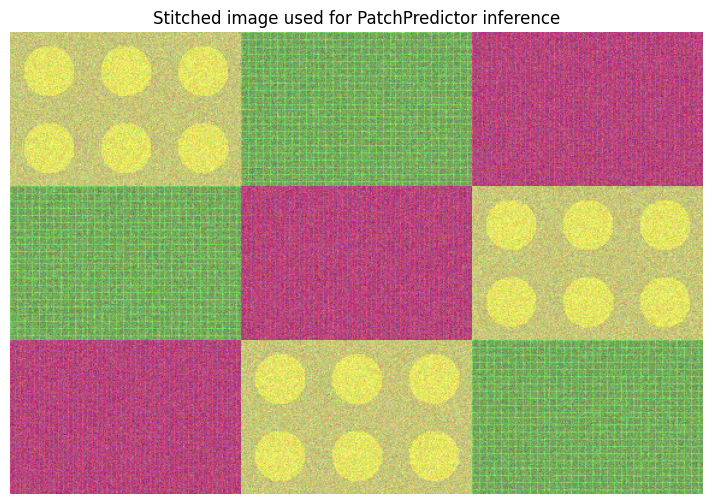

In [10]:
grid_rows, grid_cols = 6, 9
class_names = [name for name, _ in sorted(dataset.class_to_idx.items(), key=lambda item: item[1])]
rng = np.random.default_rng(21)

stitched_image = np.zeros((grid_rows * patch_size, grid_cols * patch_size, 3), dtype=np.uint8)
expected_index_map = np.zeros((grid_rows, grid_cols), dtype=np.int64)

for row in range(grid_rows):
    for col in range(grid_cols):
        class_name = class_names[(row // 2 + col // 3) % len(class_names)]
        expected_index_map[row, col] = dataset.class_to_idx[class_name]
        patch_candidates = sorted((dataset_root / class_name).glob("*.png"))
        patch_path = patch_candidates[int(rng.integers(len(patch_candidates)))]
        patch = imread(patch_path)

        y0, y1 = row * patch_size, (row + 1) * patch_size
        x0, x1 = col * patch_size, (col + 1) * patch_size
        stitched_image[y0:y1, x0:x1] = patch

stitched_image_path = output_dir / "stitched_large_image.png"
imwrite(stitched_image_path, stitched_image)

plt.figure(figsize=(12, 6))
plt.imshow(stitched_image)
plt.title("Stitched image used for PatchPredictor inference")
plt.axis("off")


In [12]:
inference_model = build_model(num_classes)
inference_model.class_dict = {index: name for name, index in dataset.class_to_idx.items()}

predictor = PatchPredictor(
    model=inference_model,
    weights=output_dir / "best_model_weights.pth",
    batch_size=16,
    num_workers=0,
    device=device,
    verbose=False,
)

predictor_output_dir = output_dir / "patchpredictor_output"

predictor_output = predictor.run(
    images=[stitched_image_path],
    patch_mode=False,
    patch_input_shape=(patch_size, patch_size),
    stride_shape=(patch_size, patch_size),
    input_resolutions=[{"units": "baseline", "resolution": 1.0}],
    auto_get_mask=False,
    return_probabilities=True,
    output_type="zarr",
    save_dir=predictor_output_dir,
)

zarr_output_path = predictor_output[stitched_image_path]
print(f"PatchPredictor output: {zarr_output_path}")


|2026-02-17|18:10:50.902| [WARNING] GPU is not compatible with torch.compile. Compatible GPUs include NVIDIA V100, A100, and H100. Speedup numbers may be lower than expected.
|2026-02-17|18:10:50.902| [WARNING] Please provide a valid ModelIOConfigABC. No default ModelIOConfigABC found.


|2026-02-17|18:10:50.903| [INFO] When providing multiple whole slide images, the outputs will be saved and the locations of outputs will be returned to the calling function when `run()` finishes successfully.


|2026-02-17|18:10:50.907| [WARNING] Raw data is None.
|2026-02-17|18:10:50.907| [WARNING] Unknown scale (no objective_power or mpp)


|2026-02-17|18:10:50.956| [INFO] Output file saved at tmp/patch_folder_training_run/patchpredictor_output/stitched_large_image.zarr.
PatchPredictor output: tmp/patch_folder_training_run/patchpredictor_output/stitched_large_image.zarr


Tile-level accuracy on stitched image: 1.000


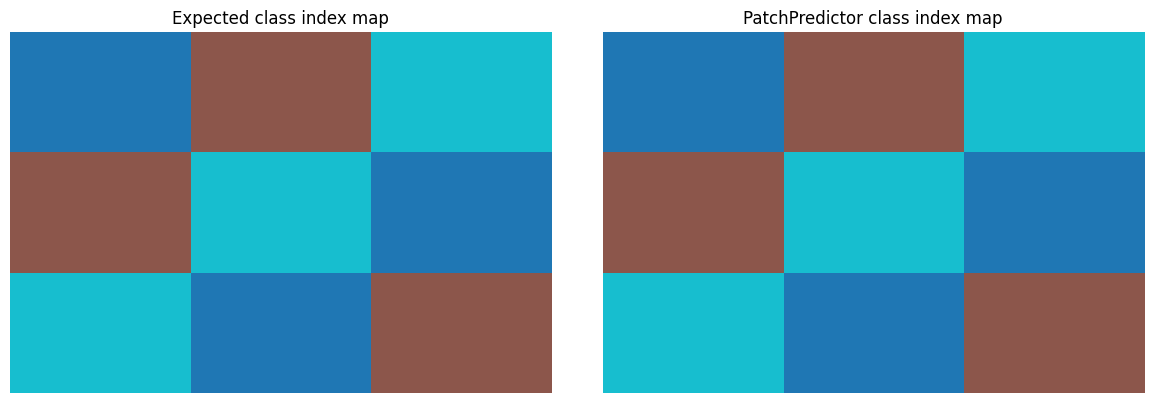

In [13]:
zarr_output = zarr.open(zarr_output_path, mode="r")
predictions = np.array(zarr_output["predictions"])
coordinates = np.array(zarr_output["coordinates"])

predicted_index_map = np.full((grid_rows, grid_cols), fill_value=-1, dtype=np.int64)
for pred_idx, (x0, y0, _, _) in zip(predictions, coordinates):
    row = int(y0 // patch_size)
    col = int(x0 // patch_size)
    predicted_index_map[row, col] = int(pred_idx)

tile_accuracy = float((predicted_index_map == expected_index_map).mean())
print(f"Tile-level accuracy on stitched image: {tile_accuracy:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(expected_index_map, cmap="tab10", vmin=0, vmax=num_classes - 1)
axes[0].set_title("Expected class index map")
axes[0].axis("off")

axes[1].imshow(predicted_index_map, cmap="tab10", vmin=0, vmax=num_classes - 1)
axes[1].set_title("PatchPredictor class index map")
axes[1].axis("off")

plt.tight_layout()


## Adapting this notebook to real data

Replace `dataset_root` with your own patch directory:

```text
my_patch_dataset/
  class_a/
    patch_0001.png
    patch_0002.png
  class_b/
    patch_0003.png
```

Then keep the same `PatchFolderClassificationDataset`, dataloaders, and `Trainer` workflow.
